In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

#funtion-for-numerator-of_target-distribution

In [29]:
def f(x):
    if x >= 1:
        return np.exp(-(x - 1) / 2) + np.exp(-(x - 1)**2)
    else:
        return np.exp((x - 1) / 3) + np.exp((x - 1)**3)

In [30]:
#Normal-PDF

In [31]:
def g(x, mu, sigma):
    return 1 / np.sqrt(2*np.pi)/sigma * np.exp(-0.5 * ((x-mu)/sigma)**2) 

#Draw Target Distribution

In [32]:
NORM_CONST = 7.16556

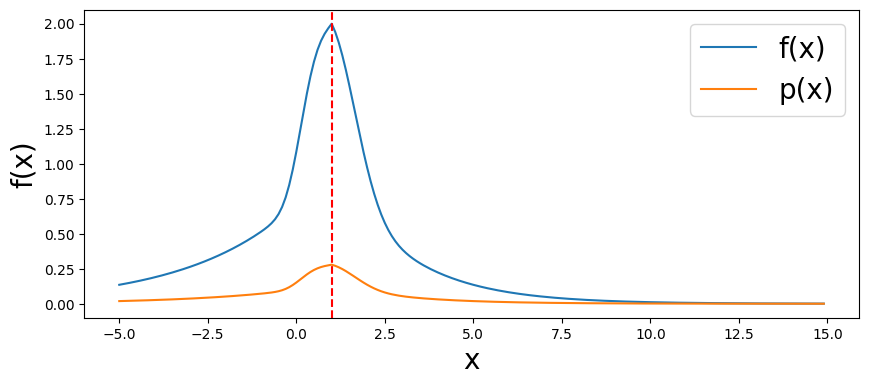

In [33]:
x_vals = np.arange(-5, 15, .1)
f_vals = [f(x) for x in x_vals]
p_vals = [f / NORM_CONST for f in f_vals]

plt.figure(figsize=(10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, p_vals)
plt.legend(['f(x)', 'p(x)'], fontsize = 20)
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)', fontsize = 20)
plt.axvline(1, color = 'r', linestyle = '--')

In [34]:
TRUE_EXP = 1.94709 / NORM_CONST
print(TRUE_EXP)

0.2717289367474419


In [35]:
#3-different methods will use to sample from p(x)

#Case 1 : Accept - Reject with N(0, 3) Candidate - (Rejection Sampling) - it suggesting us the samples from this normal(0, 3) distribution and we accpet or reject them based on some prob.

Text(0.5, 1.0, 'M = 1')

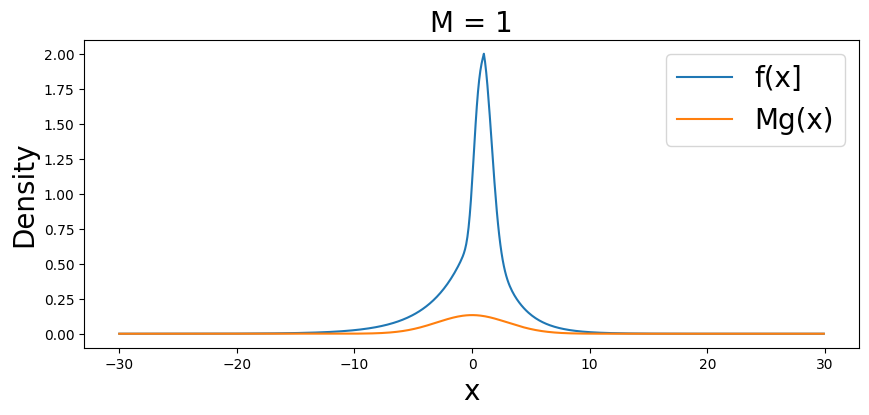

In [36]:
x_vals = np.arange(-30, 30, .1)
f_vals = [f(x) for x in x_vals]
g_vals = g(x_vals, 0, 3)
M = 1

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M*g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x]', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" %M, fontsize = 20)

Text(0.5, 1.0, 'M = 10')

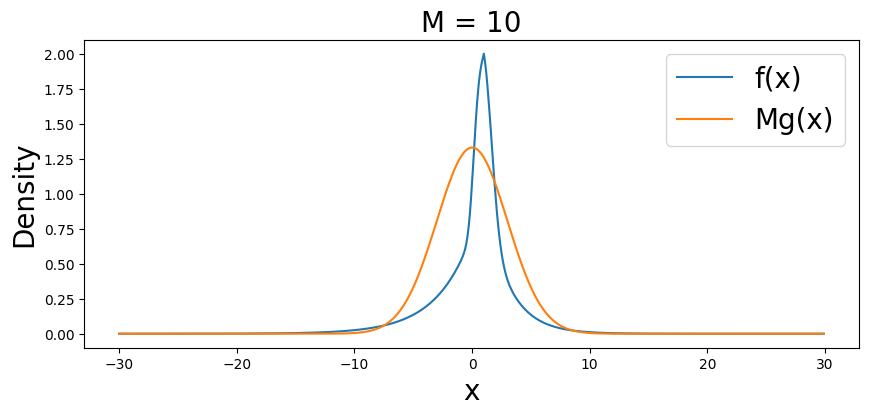

In [37]:
M = 10

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" % M, fontsize = 20)

Text(0.5, 1.0, 'M = 1000')

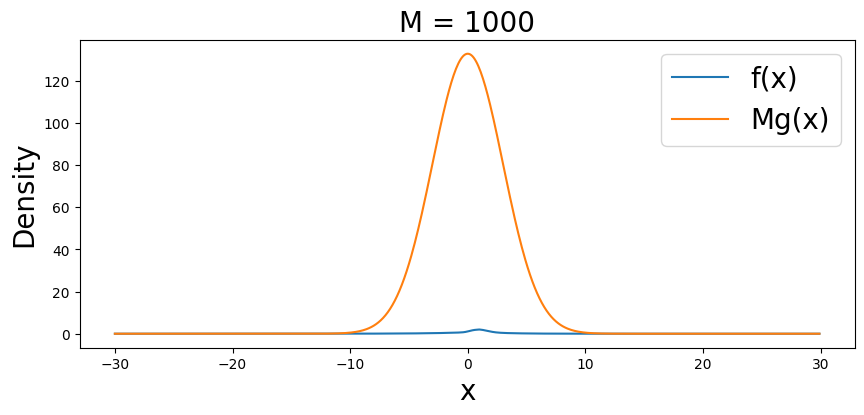

In [38]:
M = 1000

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" % M, fontsize = 20)

(0.0, 0.05)

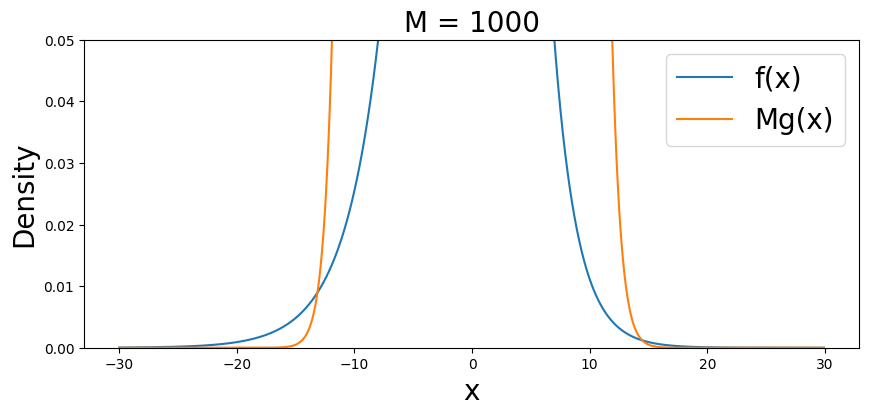

In [39]:
M = 1000

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" % M, fontsize = 20)

plt.ylim(0, .05)

In [40]:
#Collect-all-samples-here
samples = []

N = 1000000

for _ in range(N):
    #sample-a-candidate
    candidate = np.random.normal(0, 3)

    #prob.-of-accepting-this-candidate
    prob_accept = f(candidate) / (M * g(candidate, 0, 3))

    #accpet-with-calculated-prob
    if np.random.random() < prob_accept:
        samples.append(candidate)

In [41]:
print("Num samples collected: %s"%len(samples))

Num samples collected: 6704


In [42]:
#Efficiency-for-sampels-we-accept
print("Efficiency: %s"%round(len(samples) / N, 3))

Efficiency: 0.007


Text(0.5, 1.0, 'Empirical Exp. value: 0.29')

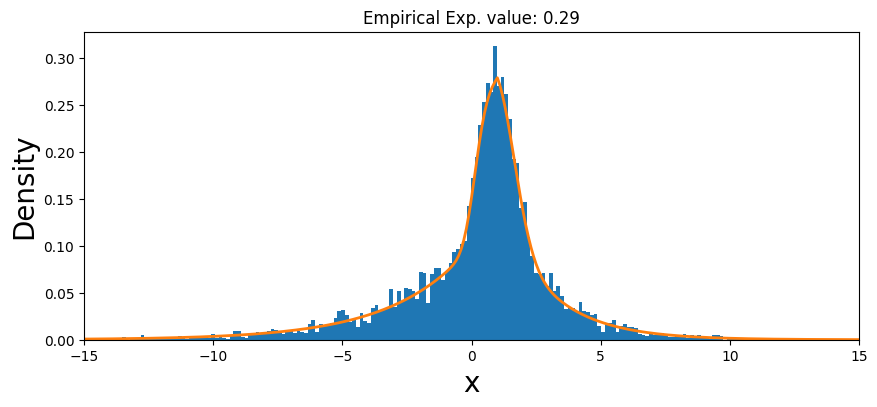

In [43]:
plt.figure(figsize = (10, 4))
plt.hist(samples, bins = 200, density = True)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.plot(x_vals, [f / NORM_CONST for f in f_vals], linewidth = 2)

plt.xlim(-15, 15)

plt.title('Empirical Exp. value: %s' %(round(np.mean(samples), 2)))

#Case - 2: Accept - Reject with N (1, 4) Candidate

Text(0.5, 1.0, 'M = 1')

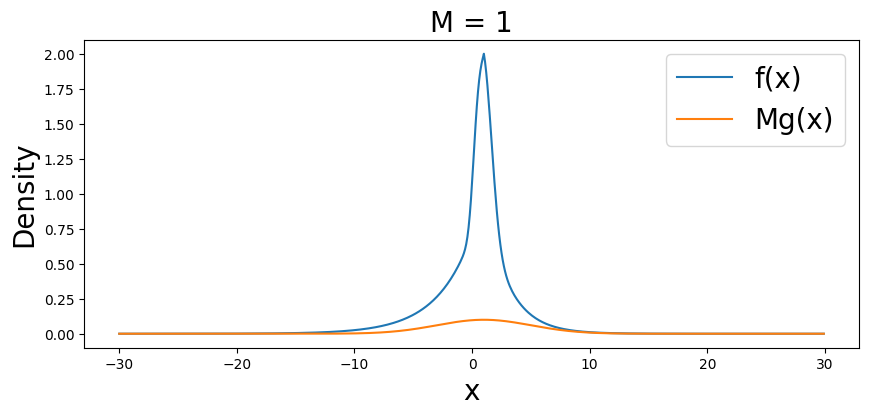

In [45]:
x_vals = np.arange(-30, 30, .1)
f_vals = [f(x) for x in x_vals]
g_vals = g(x_vals, 1, 4)
M = 1

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" %M, fontsize = 20)

Text(0.5, 1.0, 'M = 75')

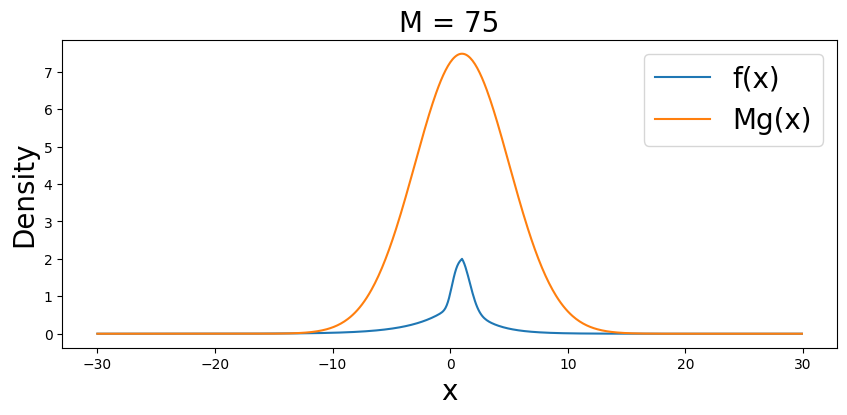

In [46]:
M = 75

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" %M, fontsize = 20)

(0.0, 0.05)

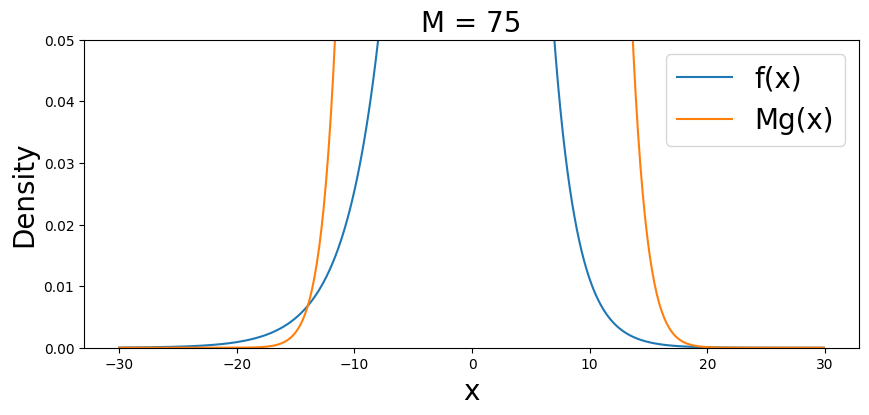

In [47]:
M = 75

plt.figure(figsize = (10, 4))
plt.plot(x_vals, f_vals)
plt.plot(x_vals, M * g_vals)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.legend(['f(x)', 'Mg(x)'], fontsize = 20)

plt.title("M = %s" %M, fontsize = 20)
plt.ylim(0, 0.05)

In [48]:
samples = []
N = 1000000
for _ in range(N):
    #candidate-from-uniform-distribution
    candidate = np.random.normal(1, 4)

    #prob-of-accepting-this-sample
    prob_accept = f(candidate) / (M * g(candidate, 1, 4))

    #accept-sample-with-this-prob
    if np.random.random() < prob_accept:
        samples.append(candidate)

In [49]:
print("Num Samples Collected: %s" % len(samples))

Num Samples Collected: 90194


In [50]:
print("Efficiency: %s" % round(len(samples) / N, 3))

Efficiency: 0.09


Text(0.5, 1.0, 'Empirical Exp. Value: 0.32\nTrue Exp. Value: 0.27')

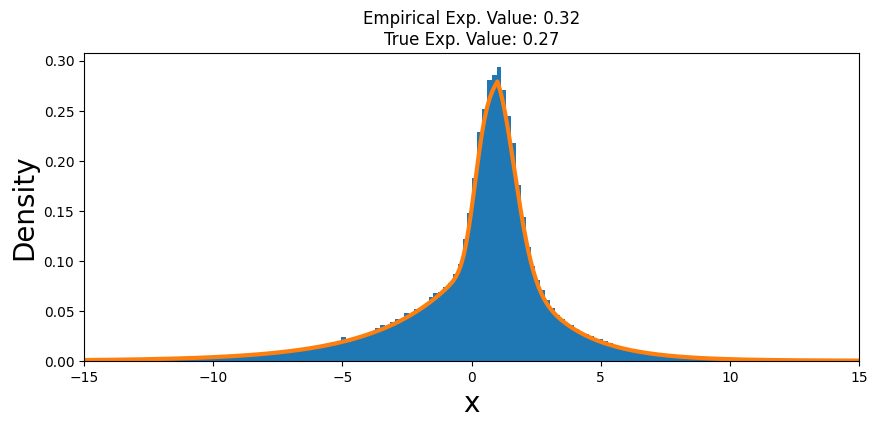

In [56]:
plt.figure(figsize = (10, 4))
plt.hist(samples, bins = 200, density = True)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.plot(x_vals, [f / NORM_CONST for f in f_vals], linewidth = 3)
plt.xlim(-15, 15)

plt.title('Empirical Exp. Value: %s\nTrue Exp. Value: %s' % (round(np.mean(samples), 2), round(np.mean(TRUE_EXP), 2)))

Text(0.5, 1.0, 'Correlation: 0.0')

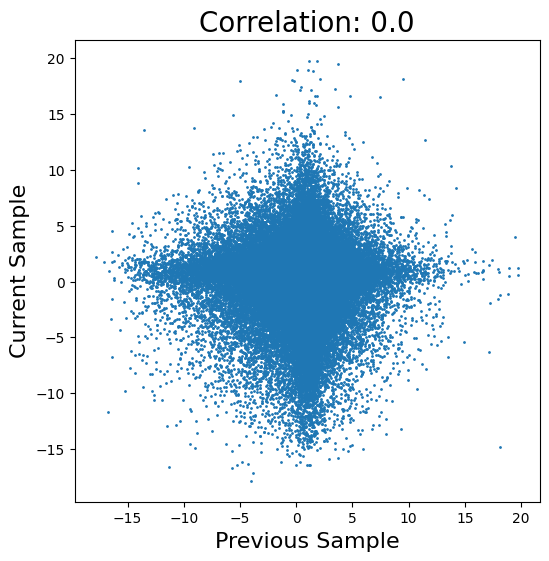

In [59]:
plt.figure(figsize = (6, 6))
plt.scatter(samples[:-1], samples[1:], s = 1)
plt.xlabel('Previous Sample', fontsize = 16)
plt.ylabel('Current Sample', fontsize = 16)
corr = round(pearsonr(samples[:-1], samples[1:])[0], 2)
plt.title('Correlation: %s'%corr, fontsize = 20)

#Case - 3 : Metropolis Algorithm with N (xprev, 4) Candidate (Under MCMC)

In [61]:
samples = [1]
num_accept = 0
for _ in range(N):
    #sample candidate from normal distribution
    candidate = np.random.normal(samples[-1], 4)

    #prob. of accepting this candidate
    prob = min(1, f(candidate) / f(samples[-1]))

    #accept with calculated prob.
    if np.random.random() < prob:
        samples.append(candidate)
        num_accept += 1
    else:
        samples.append(samples[-1])

In [62]:
burn_in = 1000
retained_samples = samples[burn_in + 1:]

In [63]:
print("Num Samples collected: %s" % len(retained_samples))

Num Samples collected: 999000


In [64]:
print('Efficiency: %s' %round(len(retained_samples) / N, 3))

Efficiency: 0.999


In [65]:
#Efficiency is far better than the accept-reject method, with MCMC method

In [66]:
print("Fraction Acceptances: %s" % (num_accept / N))

Fraction Acceptances: 0.485575


Text(0.5, 1.0, 'Empirical Exp. value: 0.26\nTrue Exp. Value: 0.27')

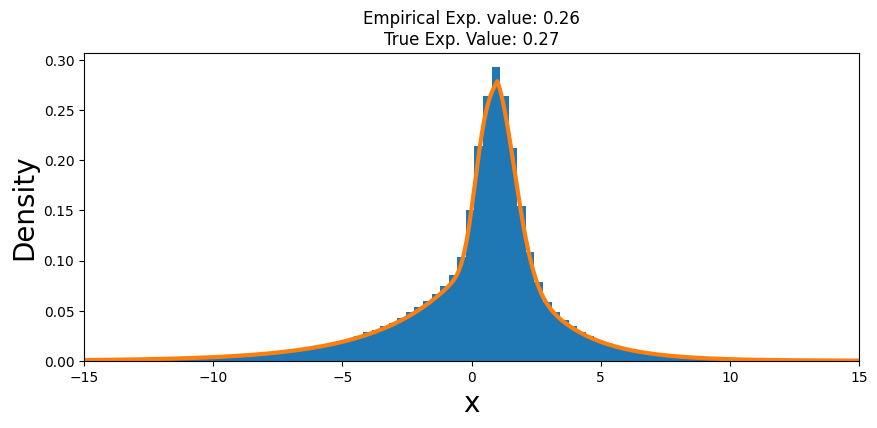

In [68]:
plt.figure(figsize = (10, 4))
plt.hist(retained_samples, bins = 200, density = True)
plt.xlabel('x', fontsize = 20)
plt.ylabel('Density', fontsize = 20)
plt.plot(x_vals, [f / NORM_CONST for f in f_vals], linewidth = 3)
plt.xlim(-15, 15)

plt.title('Empirical Exp. value: %s\nTrue Exp. Value: %s' % (round(np.mean(retained_samples), 2), round(np.mean(TRUE_EXP), 2)))

Text(0.5, 1.0, 'Correlation: 0.81')

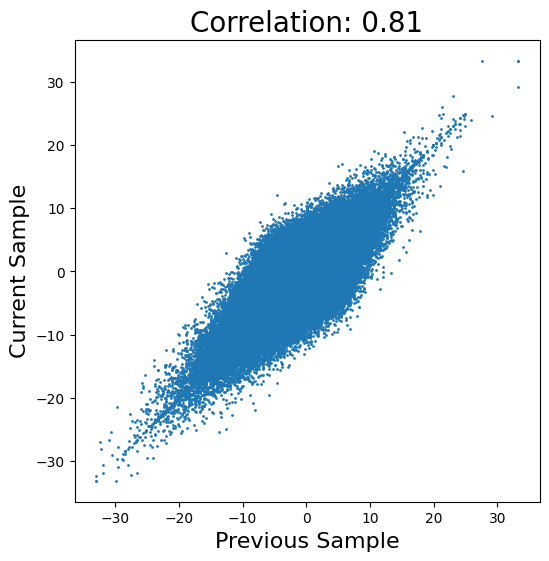

In [69]:
plt.figure(figsize = (6, 6))
plt.scatter(retained_samples[:-1], retained_samples[1:], s = 1)
plt.xlabel('Previous Sample', fontsize = 16)
plt.ylabel('Current Sample', fontsize = 16)
corr = round(pearsonr(samples[:-1], samples[1:])[0], 2)
plt.title('Correlation: %s' % corr, fontsize = 20)

In [70]:
#this is one of the drawback of MCMC is that although we get a good quantity of samples, but they are correlated with each other